# Predicting Marketing Success

### By: Aaron Villegas

In this analysis, we will investigate the UCI Bank Marketing dataset to predict whether a client subscribes to a term deposit based on variables such as demographic, education, loan status, country economic status, and other features. We start with exploratory data analysis (EDA) to understand the distributions of the features, their correlations, and whether the data has missing values and requires cleaning.

Then, we will create predictive models using logistic regression as a baseline before performing cross-validation for a more robust result. Next, we will build a random forest classifier and compare performance to identify the most effective model for this problem, using metrics such as accuracy, precision, recall, and ROC AUC. 
The insights discovered can be used to improve marketing strategy, identifying clients that are most likely to subscribe to a term deposit and optimizing marketing campaigns.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import math
import numpy as np

df = pd.read_csv('bank-additional-full.csv', sep=';', quotechar='"')
print(df.head())


   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

## Cleaning Data

In [3]:
df.isna().sum().sort_values(ascending=False)

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

We have no missing values found in this dataset.

In [4]:
#Create new binary variable for never contacted and replace 999 in pdays with 0
df['never_contacted'] = (df['pdays'] == 999).astype(int)
df['pdays'] = df['pdays'].replace(999, 0)
df['poutcome'] = df['poutcome'].fillna("nonexistent")
#Creating unknown category for missing values in categorical variables
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('unknown')

## Plotting Data

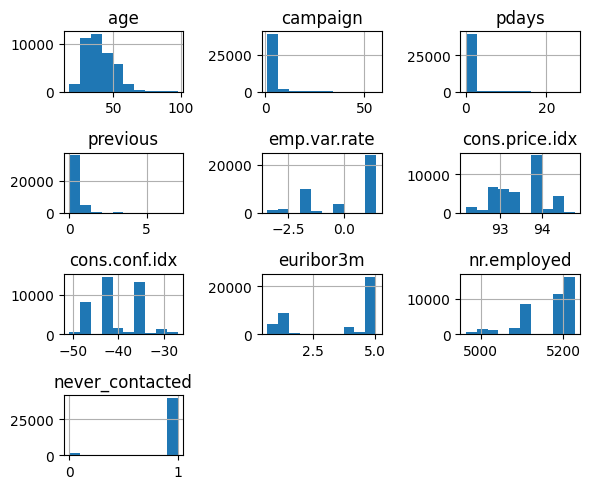

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,0,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,1


In [5]:
#Duration = Time of last call, but if duration =0, then y = no, so we can drop duration to avoid data leakage.
df.drop(columns=['duration'], inplace=True)
df.hist(figsize=(6,5))
plt.tight_layout()
plt.show()
df.head()

C:\Users\ville\AppData\Local\Temp\ipykernel_29636\2608485904.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


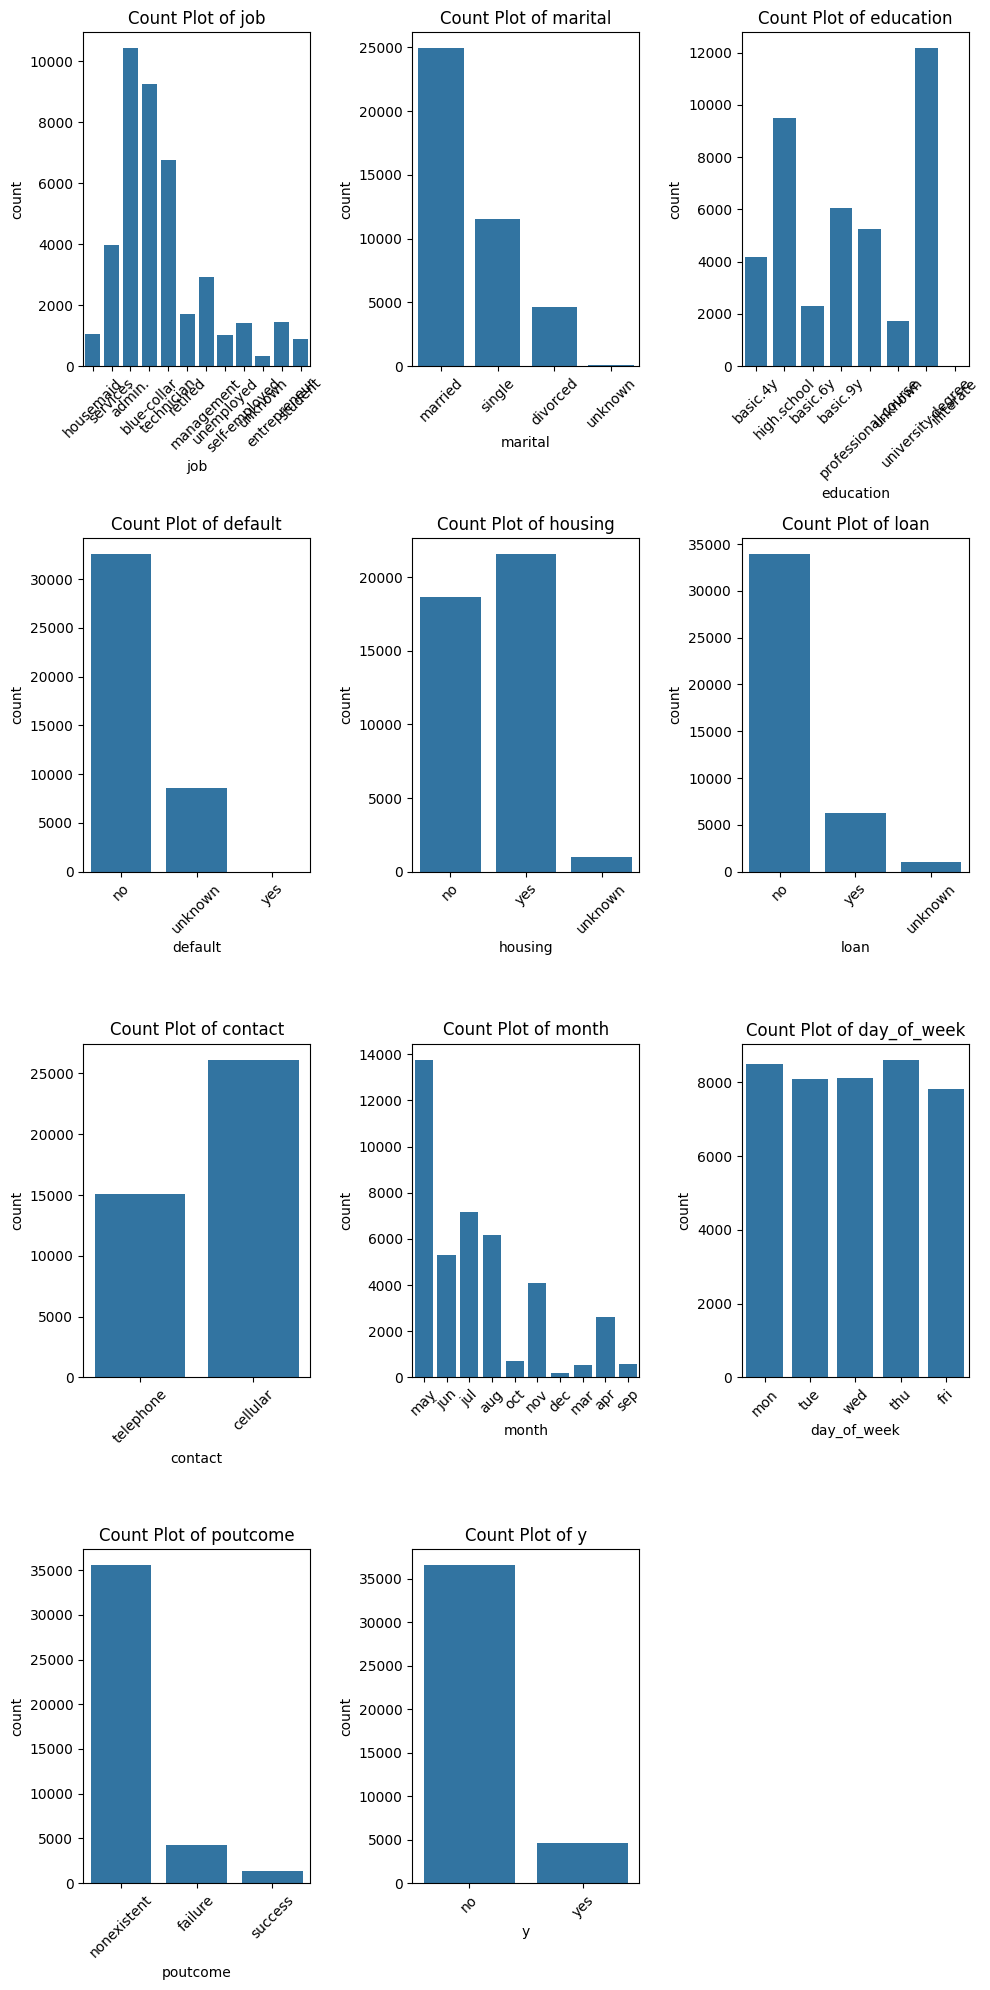

In [6]:

cat_cols = df.select_dtypes(include=['object']).columns

n_cols = 3  # number of plots per row
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Count Plot of {col}')
    axes[i].tick_params(axis='x', rotation=45)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

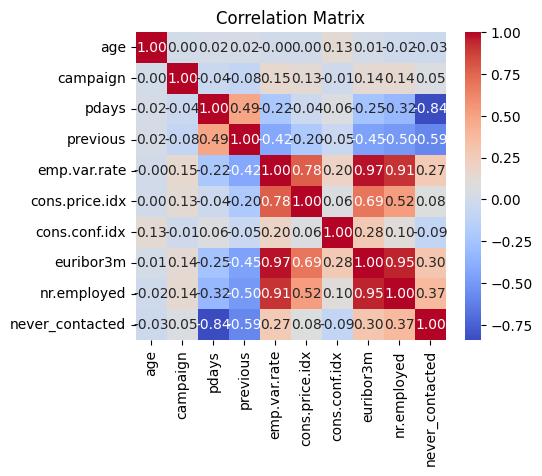

In [7]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Logistic Regression

First, we will perform regular logistic regression without cross-validation as a baseline since performance may be sensitive to the specific train-test split. Later, we will use cross-validation to better evaluate model performance by averaging performance across multiple train-test splits. Logistic regression is used in this problem because it is widely used for binary classification problems and allows us to interpret the associated coefficients for each variable to assess their importance and influence. 
The performance of the model will be measured with accuracy, precision, recall, and ROC AUC.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

X_orig = df.drop("y", axis=1)
X_log = pd.get_dummies(X_orig, drop_first=True) #Include categorical variables as binary, instead of just numeric variables
print(X_log.head())
y = df["y"].replace({"yes": 1, "no": 0}).astype(int) #Convert target variable to binary
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size = 0.2, random_state = 3)
#Scale the data to improve model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

   age  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
0   56         1      0         0           1.1          93.994   
1   57         1      0         0           1.1          93.994   
2   37         1      0         0           1.1          93.994   
3   40         1      0         0           1.1          93.994   
4   56         1      0         0           1.1          93.994   

   cons.conf.idx  euribor3m  nr.employed  never_contacted  ...  month_may  \
0          -36.4      4.857       5191.0                1  ...       True   
1          -36.4      4.857       5191.0                1  ...       True   
2          -36.4      4.857       5191.0                1  ...       True   
3          -36.4      4.857       5191.0                1  ...       True   
4          -36.4      4.857       5191.0                1  ...       True   

   month_nov  month_oct  month_sep  day_of_week_mon  day_of_week_thu  \
0      False      False      False             True           

For logistic regression, scaling features is important.

In [9]:
model = LogisticRegression(max_iter=10000)
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [10]:
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 0.90


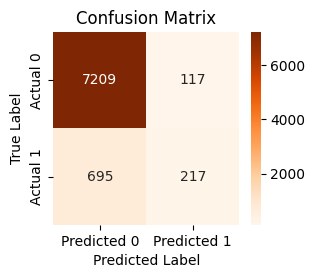

In [11]:
confusion = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(3,2.5))
sns.heatmap(confusion, 
            annot=True, 
            fmt="d", 
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

From the confusion matrix above, we see a high percentage of correctly predicted results where the customer either subscribed for a term deposit. We see a higher number of false negatives (model predicted the customer did not subscribe but actually did) compared to false positives (model predicted the customer did subscribe by actually didn't).

In [12]:
precision = confusion[1,1] / (confusion[0,1] + confusion[1,1]) if (confusion[0,1] + confusion[1,1]) > 0 else 0
print(f'Precision: {precision:.2f}')
recall = confusion[1,1] / (confusion[1,0] + confusion[1,1]) if (confusion[1,0] + confusion[1,1]) > 0 else 0
print(f'Recall: {recall:.2f}')

Precision: 0.65
Recall: 0.24


Relatively high precision of 0.65 indicates that for those the model predicts will subscribe, 65 percent actually do subscribe. Low recall of 0.19 indicates that only 24 percent of those who actually subscribed were correctly identified (tends to predict not subscribed for actual subscribers unless the model is very confident).

In [13]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:,1]
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


ROC AUC Score: 0.7901


### Logistic Regression Coefficients

In [14]:
coefficients = pd.DataFrame({
    "Feature": X_log.columns,
    "Coefficient": model.coef_[0]
})#  .sort_values(by="Coefficient", ascending=False)

coefficients_sorted = coefficients.iloc[
    coefficients["Coefficient"].abs().sort_values(ascending=False).index
]

print(coefficients_sorted.head(10))


              Feature  Coefficient
4        emp.var.rate    -2.200471
5      cons.price.idx     1.117256
7           euribor3m     0.477720
37  contact_telephone    -0.378925
8         nr.employed     0.303449
9     never_contacted    -0.233078
41          month_jun    -0.222254
43          month_may    -0.216844
44          month_nov    -0.171603
42          month_mar     0.155851


In [15]:
# from itertools import combinations
# triple_list = list(combinations(X_orig.columns,5))

# rng = np.random.default_rng(seed=10)
# random_tuples = rng.choice(triple_list, 2000)

In [16]:
from sklearn.model_selection import cross_validate
accuracy_list = []


dummy_map = {}
for col in X_train.select_dtypes(include='object'):
    dummies = pd.get_dummies(X_train[[col]], drop_first=True)
    dummy_map[col] = dummies

# Add numeric columns as themselves
for col in X_train.select_dtypes(exclude='object'):
    dummy_map[col] = X_train[[col]]
count = 0
for triple in random_tuples:
    # Select only the related dummy columns in this triple
    dfs = [dummy_map[col] for col in triple]
    X_triple_encoded = pd.concat(dfs, axis=1)    
    # Cross-validation
    cv_results = cross_validate(model, X_triple_encoded, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_accuracy = cv_results["test_score"].mean()
    
    accuracy_list.append((tuple(triple), cv_accuracy))
    random_tuples = list(random_tuples)

NameError: name 'random_tuples' is not defined

In [ ]:
from sklearn.model_selection import cross_validate

accuracy_list = []
y = y.replace({"yes": 1, "no": 0})
X_train, X_test, y_train, y_test = train_test_split(X_orig, y, test_size = 0.2, random_state = 3)
# Convert all categorical variables to dummies once
X_train_encoded = pd.get_dummies(X_train, drop_first=True)

# Cross-validation on all features
cv_results = cross_validate(model, X_train_encoded, y_train, cv=10, scoring="accuracy", n_jobs=-1)
cv_accuracy = cv_results["test_score"].mean()

accuracy_list.append(("all_features", cv_accuracy))
print(f"All features CV accuracy: {cv_accuracy:.4f}")

All features CV accuracy: 0.8993


In [ ]:
from sklearn.model_selection import cross_val_predict
X_test_encoded = pd.get_dummies(X_test, drop_first=True)
y_pred_cv = cross_val_predict(model, X_test_encoded, y_test, cv=5)
confusion = confusion_matrix(y_test, y_pred_cv)

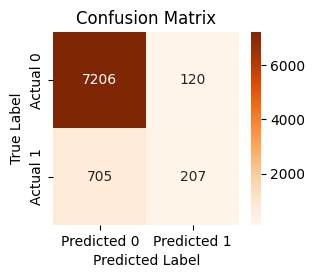

In [ ]:
plt.figure(figsize=(3,2.5))
sns.heatmap(confusion, 
            annot=True, 
            fmt="d", 
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Evaluating Cross-Validated Model

In [ ]:
print(f"Accuracy: {cv_accuracy:.4f}")
precision = confusion[1,1] / (confusion[0,1] + confusion[1,1]) if (confusion[0,1] + confusion[1,1]) > 0 else 0
print(f'Precision: {precision:.2f}')
recall = confusion[1,1] / (confusion[1,0] + confusion[1,1]) if (confusion[1,0] + confusion[1,1]) > 0 else 0
print(f'Recall: {recall:.2f}')
y_prob = model.predict_proba(X_test_scaled)[:,1]
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


Accuracy: 0.8993
Precision: 0.63
Recall: 0.23
Cross-Validation ROC AUC Score: 0.7901


Above are the accuracy metrics for the cross-validated logistic regression model. The model shows high accuracy, moderate precision, relatively low recall, and a moderate ROC Area Under Curve score. In this case, a focus on precision would be more beneficial from a business sense, since a false positive (falsely predicting a customer subscribes when they don't) is likely less costly than false negatives (falsely predicting a customer doesn't subscribe when they do).

## Random Forest Model

Random forests are useful for datasets with non-linear relationships/decision boundaries, which logistic regression may struggle with. By averaging many decision trees, random forests are less prone to overfitting and less vulnerable to outliers. This makes random forests well-suited for this classification problem of predicting client subscriptions and highlighting important features to consider in marketing strategy.

Training a model like random forests involves setting some hyperparameters which are not changed when the model is trained. Some of these parameters include the number of estimators (n_estimators), the amount of available features a decision tree can consider to split a node (max_features), the maximum depth of each decision tree (max_depth), and the minimum number of samples per leaf (min_samples_leaf). I set balance_class_weight as 'balanced' since the proportion of "yes" is low compared to the proportion of "no" for customers who subscribed to a term deposit. Increasing the number of decision trees reduces variance since there are more decision trees to average from, but increases training time. Setting balance_class_weight reduces the bias from the low amount of data on the minority class of "yes". 

In [ ]:
#Test-train split again and one-hot encoding of categorical variables for random forest model
X_train, X_test, y_train, y_test = train_test_split(X_log, y, test_size = 0.2, random_state = 3)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

### Searching for the best hyperparameters

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
    "class_weight": ["balanced", None]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=3),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train_encoded, y_train)

print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_

KeyboardInterrupt: 

### Random Forest Results

Random Forest Accuracy: 0.8529


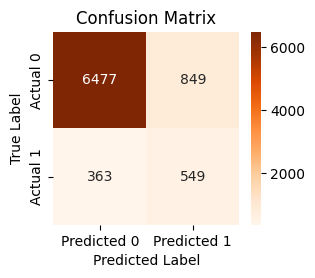

In [ ]:
best_rf.fit(X_train_encoded, y_train)
y_pred_rf = best_rf.predict(X_test_encoded)

confusion_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(3,2.5))
sns.heatmap(confusion_rf, 
            annot=True, 
            fmt="d", 
            cmap="Oranges",
            xticklabels=["Predicted 0", "Predicted 1"],
            yticklabels=["Actual 0", "Actual 1"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [28]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')
precision = confusion_rf[1,1] / (confusion_rf[0,1] + confusion_rf[1,1]) if (confusion_rf[0,1] + confusion_rf[1,1]) > 0 else 0
print(f'Precision: {precision:.2f}')
recall = confusion_rf[1,1] / (confusion_rf[1,0] + confusion_rf[1,1]) if (confusion_rf[1,0] + confusion_rf[1,1]) > 0 else 0
print(f'Recall: {recall:.2f}')
y_prob = best_rf.predict_proba(X_test_encoded)[:,1]
print(f"ROC AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Random Forest Accuracy: 0.8529
Precision: 0.39
Recall: 0.60
ROC AUC Score: 0.8039


## Conclusion